In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Crear el Dataset Billetes

In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
from tqdm import tqdm

# === CONFIGURACIÓN ===
base_path = "/content/drive/MyDrive/SIS420-IA/Proyecto/Billetes"
series = ["Antigua", "Serie_A", "Serie_B"]
denominaciones = ["10", "20", "50", "100", "200"]

# Mapeo de etiquetas
label_map = {"10": 0, "20": 1, "50": 2, "100": 3, "200": 4}

# === FUNCIÓN PARA PROCESAR IMÁGENES A CSV ===
def crear_dataset_csv_pixels():
    print("CREANDO DATASET CSV DE PÍXELES RGB")
    print("📊 Cada imagen 500x500 RGB → 750000 columnas + label")
    print("💰 MONEDA: BOLIVIANOS")
    print("=" * 60)

    # Lista para almacenar todos los datos
    todos_los_datos = []

    for denom in denominaciones:
        print(f"\n📁 Procesando: {denom} Bolivianos")
        label = label_map[denom]

        for serie in series:
            # Rutas de anverso y reverso
            path_anverso = os.path.join(base_path, serie, denom, "augmented_A_500")
            path_reverso = os.path.join(base_path, serie, denom, "augmented_R_500")

            if not os.path.exists(path_anverso) or not os.path.exists(path_reverso):
                print(f"   ❌ Saltando {serie} - carpetas no encontradas")
                continue

            contador = 0

            # Procesar imágenes de ANVERSO
            for img_name in tqdm(os.listdir(path_anverso), desc=f"   {serie} Anverso"):
                if img_name.endswith('.png'):
                    img_path = os.path.join(path_anverso, img_name)
                    fila_imagen = procesar_imagen(img_path, label)
                    if fila_imagen is not None:
                        todos_los_datos.append(fila_imagen)
                        contador += 1

            # Procesar imágenes de REVERSO
            for img_name in tqdm(os.listdir(path_reverso), desc=f"   {serie} Reverso"):
                if img_name.endswith('.png'):
                    img_path = os.path.join(path_reverso, img_name)
                    fila_imagen = procesar_imagen(img_path, label)
                    if fila_imagen is not None:
                        todos_los_datos.append(fila_imagen)
                        contador += 1

            print(f"   ✅ {serie}: {contador} imágenes procesadas")

    return todos_los_datos

def procesar_imagen(img_path, label):
    """Convierte una imagen 64x64 RGB a fila CSV"""
    try:
        # Leer imagen
        img = cv2.imread(img_path)
        if img is None:
            return None

        # Convertir a RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Verificar dimensiones
        if img_rgb.shape != (500, 500, 3):
            print(f"      ⚠️ Dimensiones incorrectas: {img_rgb.shape}")
            return None

        # Aplanar imagen: 500x500x3 → 750000 valores
        pixels_flat = img_rgb.reshape(-1).astype(np.uint8)

        # Crear fila: [label, pixel1, pixel2, ..., pixel..]
        fila = [label] + pixels_flat.tolist()

        return fila

    except Exception as e:
        print(f"      ❌ Error procesando {img_path}: {e}")
        return None

# === CREAR DATAFRAME Y GUARDAR ===
def guardar_dataset_csv(datos):
    print("\n" + "=" * 60)
    print("💾 GUARDANDO DATASET CSV")
    print("=" * 60)

    # Crear nombres de columnas
    columnas = ['label']
    for i in range(500 * 500 * 3):  # 750000 píxeles
        columnas.append(f'pixel_{i+1}')

    # Crear DataFrame
    df = pd.DataFrame(datos, columns=columnas)

    # Mezclar aleatoriamente
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Guardar CSV
    output_path = "/content/drive/MyDrive/SIS420-IA/Proyecto/billetes_pixels_dataset.csv"
    df.to_csv(output_path, index=False)

    print(f"✅ CSV guardado en: {output_path}")
    print(f"📊 Dimensiones del dataset: {df.shape}")
    print(f"📁 Tamaño aproximado: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

    return df, output_path

# === ESTADÍSTICAS ===
def mostrar_estadisticas(df):
    print("\n" + "=" * 60)
    print("📊 ESTADÍSTICAS DEL DATASET")
    print("=" * 60)

    print(f"🎯 Total de imágenes: {len(df)}")
    print(f"📐 Dimensiones por imagen: 500x500x3 = 750000 píxeles")

    print("\n💰 Distribución por denominación:")
    for denom, label in label_map.items():
        count = len(df[df['label'] == label])
        print(f"   Label {label} ({denom} Bolivianos): {count} imágenes")

    print(f"\n🎨 Rango de valores de píxeles: 0-255 (RGB)")
    print(f"📈 Memoria del DataFrame: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

# === EJECUTAR ===
if __name__ == "__main__":
    print("🚀 CREANDO DATASET CSV DE PÍXELES RGB")
    print("📍 Formato: label + 750000 columnas de píxeles")

    # Procesar imágenes
    datos = crear_dataset_csv_pixels()

    if not datos:
        print("❌ No se encontraron imágenes para procesar")
        exit()

    # Guardar CSV
    df, csv_path = guardar_dataset_csv(datos)

    # Mostrar estadísticas
    mostrar_estadisticas(df)

    # Mostrar ejemplo
    print("\n📋 Ejemplo de una fila (primeros 10 píxeles):")
    print(f"Label: {df.iloc[0]['label']}")
    print(f"Píxeles 1-10: {df.iloc[0, 1:11].tolist()}")

    print("\n" + "=" * 60)
    print("✅ DATASET CSV DE PÍXELES CREADO EXITOSAMENTE")
    print("=" * 60)

🚀 CREANDO DATASET CSV DE PÍXELES RGB
📍 Formato: label + 12288 columnas de píxeles
CREANDO DATASET CSV DE PÍXELES RGB
📊 Cada imagen 64x64 RGB → 12288 columnas + label
💰 MONEDA: BOLIVIANOS

📁 Procesando: 10 Bolivianos


   Antigua Reverso: 100%|██████████| 200/200 [00:01<00:00, 137.37it/s]


   ✅ Antigua: 400 imágenes procesadas


   Serie_A Reverso: 100%|██████████| 200/200 [00:01<00:00, 125.06it/s]


   ✅ Serie_A: 400 imágenes procesadas


...

   ✅ Antigua: 400 imágenes procesadas


   Serie_A Reverso: 100%|██████████| 200/200 [00:01<00:00, 112.82it/s]


   ✅ Serie_A: 400 imágenes procesadas


   Serie_B Reverso: 100%|██████████| 200/200 [00:01<00:00, 128.89it/s]


   ✅ Serie_B: 400 imágenes procesadas

💾 GUARDANDO DATASET CSV
✅ CSV guardado en: /content/drive/MyDrive/SIS420-IA/Proyecto/billetes_pixels_dataset.csv
📊 Dimensiones del dataset: (6000, 12289)
📁 Tamaño aproximado: 562.55 MB

📊 ESTADÍSTICAS DEL DATASET
🎯 Total de imágenes: 6000
📐 Dimensiones por imagen: 64x64x3 = 12288 píxeles

💰 Distribución por denominación:
   Label 0 (10 Bolivianos): 1200 imágenes
   Label 1 (20 Bolivianos): 1200 imágenes
   Label 2 (50 Bolivianos): 1200 imágenes
   Label 3 (100 Bolivianos): 1200 imágenes
   Label 4 (200 Bolivianos): 1200 imágenes

🎨 Rango de valores de píxeles: 0-255 (RGB)
📈 Memoria del DataFrame: 562.55 MB

📋 Ejemplo de una fila (primeros 10 píxeles):
Label: 1
Píxeles 1-10: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

✅ DATASET CSV DE PÍXELES CREADO EXITOSAMENTE


In [ ]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
#from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# Librería para manejo de datos
import pandas as pd

#Para separa el Dataset 20% y 80% para diferentes pruebas
from sklearn.model_selection import train_test_split

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [ ]:
# Cargar el conjunto de datos que convierte el archivo CSV en un DataFrame de pandas
data = pd.read_csv('/content/drive/MyDrive/SIS420-IA/Proyecto/billetes_pixels_dataset.csv')  # Carga el dataset
#data

🔍 INICIANDO VERIFICACIÓN DEL DATASET CSV
📊 DIMENSIONES: (6000, 12289)
🎯 Número de imágenes: 6000
📐 Características por imagen: 12288 píxeles

1. VERIFICACIÓN DE ESTRUCTURA
✅ Columnas esperadas: 12289
✅ Columnas encontradas: 12289
✅ Estructura correcta: True

📋 Primeras 5 columnas: ['label', 'pixel_1', 'pixel_2', 'pixel_3', 'pixel_4']
📋 Últimas 5 columnas: ['pixel_12284', 'pixel_12285', 'pixel_12286', 'pixel_12287', 'pixel_12288']

2. VERIFICACIÓN DE ETIQUETAS
✅ Etiquetas únicas: [0 1 2 3 4]
✅ Rango de etiquetas: 0 a 4

📈 Distribución por clase:
   Clase 0: 1200 imágenes (20.0%)
   Clase 1: 1200 imágenes (20.0%)
   Clase 2: 1200 imágenes (20.0%)
   Clase 3: 1200 imágenes (20.0%)
   Clase 4: 1200 imágenes (20.0%)

3. VERIFICACIÓN DE PÍXELES
✅ Rango mínimo de píxeles: 0
✅ Rango máximo de píxeles: 255
✅ Valores dentro de rango RGB (0-255): True
✅ Valores nulos en el dataset: 0

4. VERIFICACIÓN VISUAL - RECONSTRUIR IMAGEN


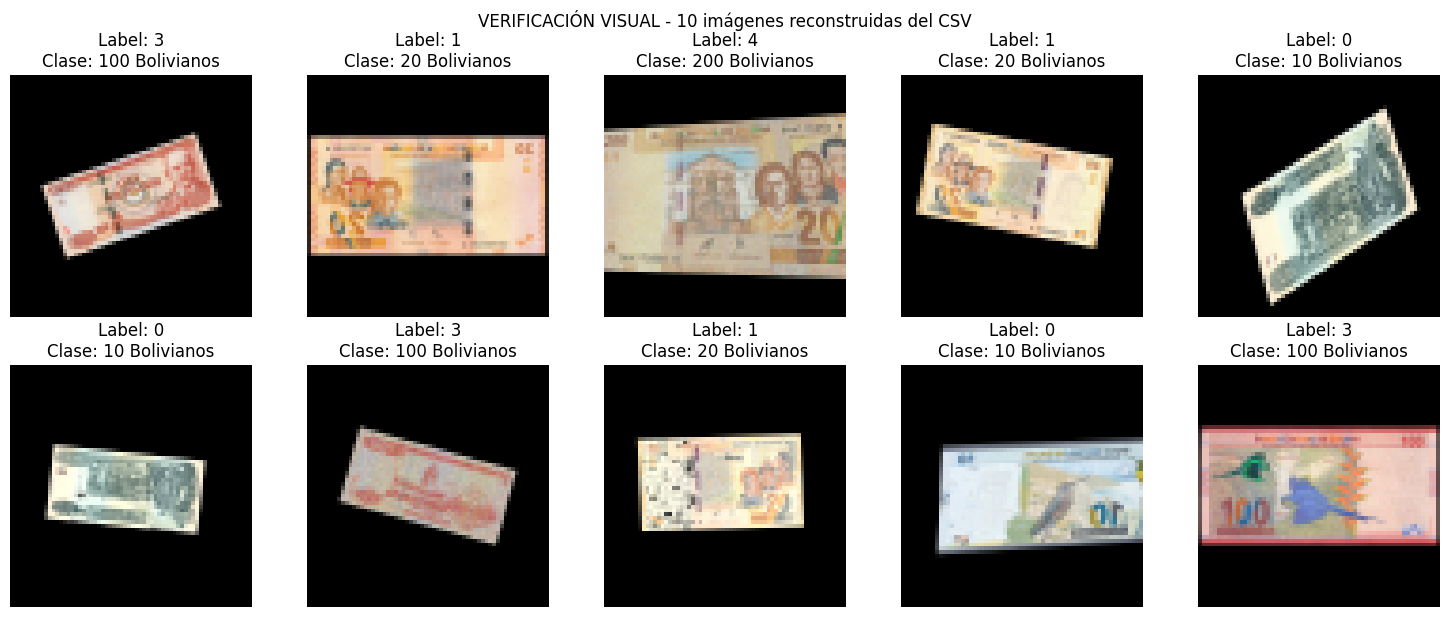


5. VERIFICACIÓN DE INTEGRIDAD
✅ Píxeles por imagen: 12288
✅ Correcto (12288): True

📝 Tipos de datos:
   Label: int64
   Píxeles: int64

6. ESTADÍSTICAS DETALLADAS POR CLASE

💰 10 Bolivianos:
   📊 Imágenes: 1200
   📏 Promedio de intensidad: 62.2
   📐 Desviación estándar: 87.4
   🎨 Rango: [0, 255]

💰 20 Bolivianos:
   📊 Imágenes: 1200
   📏 Promedio de intensidad: 63.3
   📐 Desviación estándar: 89.6
   🎨 Rango: [0, 255]

💰 50 Bolivianos:
   📊 Imágenes: 1200
   📏 Promedio de intensidad: 71.5
   📐 Desviación estándar: 89.1
   🎨 Rango: [0, 255]

💰 100 Bolivianos:
   📊 Imágenes: 1200
   📏 Promedio de intensidad: 60.6
   📐 Desviación estándar: 85.8
   🎨 Rango: [0, 255]

💰 200 Bolivianos:
   📊 Imágenes: 1200
   📏 Promedio de intensidad: 59.1
   📐 Desviación estándar: 83.1
   🎨 Rango: [0, 255]

🎉==================================================
✅ VERIFICACIÓN COMPLETADA - DATASET CORRECTO
✓ Estructura de columnas correcta
✓ Etiquetas en rango esperado
✓ Píxeles en rango RGB (0-255)
✓ Sin valo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === CARGA Y VERIFICACIÓN BÁSICA ===
def verificar_dataset(csv_path):
    print("🔍 INICIANDO VERIFICACIÓN DEL DATASET CSV")
    print("=" * 60)

    # Cargar dataset
    df = pd.read_csv(csv_path)

    print(f"📊 DIMENSIONES: {df.shape}")
    print(f"🎯 Número de imágenes: {len(df)}")
    print(f"📐 Características por imagen: {df.shape[1] - 1} píxeles")

    # === VERIFICACIÓN 1: ESTRUCTURA ===
    print("\n" + "=" * 50)
    print("1. VERIFICACIÓN DE ESTRUCTURA")
    print("=" * 50)

    # Verificar columnas
    expected_columns = 750001  # label + 750000 píxeles
    actual_columns = df.shape[1]
    print(f"✅ Columnas esperadas: {expected_columns}")
    print(f"✅ Columnas encontradas: {actual_columns}")
    print(f"✅ Estructura correcta: {expected_columns == actual_columns}")

    # Verificar nombres de columnas
    print(f"\n📋 Primeras 5 columnas: {df.columns[:5].tolist()}")
    print(f"📋 Últimas 5 columnas: {df.columns[-5:].tolist()}")

    # === VERIFICACIÓN 2: ETIQUETAS ===
    print("\n" + "=" * 50)
    print("2. VERIFICACIÓN DE ETIQUETAS")
    print("=" * 50)

    labels = df['label'].unique()
    labels.sort()
    print(f"✅ Etiquetas únicas: {labels}")
    print(f"✅ Rango de etiquetas: {labels.min()} a {labels.max()}")

    # Distribución de clases
    print("\n📈 Distribución por clase:")
    for label in labels:
        count = len(df[df['label'] == label])
        print(f"   Clase {label}: {count} imágenes ({count/len(df)*100:.1f}%)")

    # === VERIFICACIÓN 3: VALORES DE PÍXELES ===
    print("\n" + "=" * 50)
    print("3. VERIFICACIÓN DE PÍXELES")
    print("=" * 50)

    # Obtener solo columnas de píxeles
    pixel_columns = [col for col in df.columns if col.startswith('pixel_')]
    pixel_data = df[pixel_columns]

    print(f"✅ Rango mínimo de píxeles: {pixel_data.values.min()}")
    print(f"✅ Rango máximo de píxeles: {pixel_data.values.max()}")
    print(f"✅ Valores dentro de rango RGB (0-255): {(pixel_data.values >= 0).all() and (pixel_data.values <= 255).all()}")

    # Verificar valores nulos
    nulos = df.isnull().sum().sum()
    print(f"✅ Valores nulos en el dataset: {nulos}")

    # === VERIFICACIÓN 4: RECONSTRUIR IMAGEN ===
    print("\n" + "=" * 50)
    print("4. VERIFICACIÓN VISUAL - RECONSTRUIR IMAGEN")
    print("=" * 50)

    # Reconstruir algunas imágenes para verificar
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()

    for i in range(10):
        # Obtener una fila aleatoria
        idx = np.random.randint(0, len(df))
        fila = df.iloc[idx]

        # Extraer label y píxeles
        label = fila['label']
        pixels = fila[pixel_columns].values

        # Reconstruir imagen 500x500x3
        imagen = pixels.reshape(500, 500, 3).astype(np.uint8)

        # Mostrar
        axes[i].imshow(imagen)
        axes[i].set_title(f'Label: {label}\nClase: {get_denominacion(label)}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.suptitle('VERIFICACIÓN VISUAL - 10 imágenes reconstruidas del CSV', y=1.02)
    plt.show()

    # === VERIFICACIÓN 5: INTEGRIDAD DE DATOS ===
    print("\n" + "=" * 50)
    print("5. VERIFICACIÓN DE INTEGRIDAD")
    print("=" * 50)

    # Verificar que todas las imágenes tienen 750000 píxeles
    pixeles_por_imagen = len(pixel_columns)
    print(f"✅ Píxeles por imagen: {pixeles_por_imagen}")
    print(f"✅ Correcto (750000): {pixeles_por_imagen == 750000}")

    # Verificar tipos de datos
    print(f"\n📝 Tipos de datos:")
    print(f"   Label: {df['label'].dtype}")
    print(f"   Píxeles: {pixel_data.iloc[:,0].dtype}")

    return df

def get_denominacion(label):
    denominaciones = {0: "10 Bolivianos", 1: "20 Bolivianos", 2: "50 Bolivianos",
                      3: "100 Bolivianos", 4: "200 Bolivianos"}
    return denominaciones.get(label, "Desconocido")

# === VERIFICACIÓN ADICIONAL: ESTADÍSTICAS POR CLASE ===
def estadisticas_detalladas(df):
    print("\n" + "=" * 50)
    print("6. ESTADÍSTICAS DETALLADAS POR CLASE")
    print("=" * 50)

    pixel_columns = [col for col in df.columns if col.startswith('pixel_')]

    for label in sorted(df['label'].unique()):
        subset = df[df['label'] == label]
        pixels_subset = subset[pixel_columns]

        print(f"\n💰 {get_denominacion(label)}:")
        print(f"   📊 Imágenes: {len(subset)}")
        print(f"   📏 Promedio de intensidad: {pixels_subset.values.mean():.1f}")
        print(f"   📐 Desviación estándar: {pixels_subset.values.std():.1f}")
        print(f"   🎨 Rango: [{pixels_subset.values.min()}, {pixels_subset.values.max()}]")

# === EJECUTAR VERIFICACIÓN ===
if __name__ == "__main__":
    csv_path = "/content/drive/MyDrive/SIS420-IA/Proyecto/billetes_pixels_dataset.csv"

    try:
        df = verificar_dataset(csv_path)
        estadisticas_detalladas(df)

        print("\n🎉" + "=" * 50)
        print("✅ VERIFICACIÓN COMPLETADA - DATASET CORRECTO")
        print("=" * 50)
        print("✓ Estructura de columnas correcta")
        print("✓ Etiquetas en rango esperado")
        print("✓ Píxeles en rango RGB (0-255)")
        print("✓ Sin valores nulos")
        print("✓ Imágenes reconstruibles")
        print("🎯 Dataset listo para entrenamiento!")

    except Exception as e:
        print(f"\n❌ ERROR en verificación: {e}")